# Exploratory Data Analysis. BEA 2026 Shared Task: Vocabulary Difficulty Prediction

**Team Data Asgardians. Notebook 1 of 4 in the reproducibility pipeline.**

This notebook presents a comprehensive exploratory analysis of the shared task data and of the linguistic features engineered for difficulty prediction. It runs on CPU only and requires the official task data, obtainable by cloning `https://github.com/britishcouncil/bea2026st` into the working directory. All outputs shown here were produced during the original analysis and are preserved so the notebook can be inspected without re-execution.

### Structure
1. **Data Overview**: structure, distribution, data quality
2. **Target Variable**: GLMM_score by L1, POS, and split
3. **Feature Engineering**: 22 linguistic features (phonology, morphology, WordNet, CMU)
4. **Feature Distributions**: histograms, normality, outliers
5. **Correlation with Target**: feature by L1 (which features help?)
6. **Multicollinearity**: which features are redundant?
7. **Feature Selection**: automatic (|r| > 0.85)
8. **Selected Features vs Target**: detailed scatter plots
9. **L1-specific Interactions**: do different features matter by language?
10. **Cross-L1 Comparison**: parallel items
11. **Extreme Words**: easiest and hardest words by L1
12. **Modeling Implications**: main takeaways


## 0. Setup

In [ ]:
import math
import re
import warnings
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, shapiro, normaltest, spearmanr
import nltk
from nltk.corpus import cmudict, wordnet as wn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk", palette="Set2")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Download NLTK resources
for pkg in ["wordnet", "omw-1.4", "cmudict"]:
    nltk.download(pkg, quiet=True)

# Paths
# Adjust BASE depending on your environment (local or Colab)
BASE = Path("bea2026st")  # local
if not BASE.exists():
    BASE = Path("/content/british_council_test/bea2026st")  # Colab

DATA_DIR = BASE / "data"
FIG_DIR = BASE / "results" / "eda_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

L1S = ["es", "de", "cn"]
L1_LABELS = {"es": "🇪🇸 Spanish", "de": "🇩🇪 German", "cn": "🇨🇳 Mandarin"}
L1_COLORS = {"es": "#1D9E75", "de": "#D85A30", "cn": "#378ADD"}
TARGET = "GLMM_score"

print(f"BASE: {BASE}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR: {FIG_DIR}")


BASE: bea2026st
DATA_DIR: bea2026st\data


## 1. Data Overview

In [ ]:
def load_split(split):
    frames = []
    for l1 in L1S:
        path = DATA_DIR / split / l1 / f"kvl_shared_task_{l1}_{split}.csv"
        if path.exists():
            df = pd.read_csv(path)
            df["split"] = split
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

train = load_split("train")
dev = load_split("dev")
all_data = pd.concat([train, dev], ignore_index=True)

print(f"Train: {train.shape} | Dev: {dev.shape} | Total: {all_data.shape}")
print(f"\nColumns: {list(train.columns)}")
print(f"\nDistribution by L1:")
for name, df in [("Train", train), ("Dev", dev)]:
    print(f"  {name}: {df['L1'].value_counts().to_dict()}")

print(f"\nMissing values: {train.isnull().sum().sum()} (train) | {dev.isnull().sum().sum()} (dev)")
print(f"\nData types:")
print(train.dtypes.to_string())


Train: (18273, 9) | Dev: (2031, 9) | Total: (20304, 9)

Columnas: ['item_id', 'L1', 'en_target_word', 'en_target_pos', 'en_target_clue', 'L1_source_word', 'L1_context', 'GLMM_score', 'split']

Distribución por L1:
  Train: {'es': 6091, 'de': 6091, 'cn': 6091}
  Dev: {'es': 677, 'de': 677, 'cn': 677}

Missing values: 0 (train) | 0 (dev)

Tipos de datos:
item_id             int64
L1                    str
en_target_word        str
en_target_pos         str
en_target_clue        str
L1_source_word        str
L1_context            str
GLMM_score        float64
split                 str


In [3]:
train.head(10)


,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split
0,1,es,span,noun,s___,lapso,El eclipse solar fue visible durante un breve ...,-3.264099,train
1,2,es,radically,adverb,r________,fundamentalmente,Los métodos nuevos son fundamentalmente difere...,-1.871782,train
2,3,es,supermarket,noun,s__________,supermercado,Vamos al supermercado y compramos todo lo que ...,2.733109,train
3,4,es,airplane,noun,a_______,avión,El avión despegó tres horas tarde.,0.054737,train
4,5,es,trying,adjective,t_____,difícil,"Es un tiempo muy difícil, sin ninguna duda.",-4.086776,train
5,6,es,racing,noun,r_____,carreras,¿Te puedes creer que se ha comprado un coche d...,-0.071782,train
6,7,es,sleep,verb,s____,dormir,Es importante dormir bien si estás enfermo.,3.682800,train
7,8,es,military,noun,m_______,ejército,El ejército no parecía nada contento con los c...,-0.086130,train
8,9,es,capacity,noun,c_______,cabida,La sala da cabida a dos mil personas.,-1.726756,train
9,10,es,cane,noun,c___,bastón,Siempre veras a mi abuelo caminando con su bastón,-0.837535,train


## 2. Target Variable: GLMM_score

`GLMM_score` is the estimated difficulty of a vocabulary item, derived from a generalized linear mixed model fitted to learner responses. Higher values indicate easier words and lower values indicate harder words.


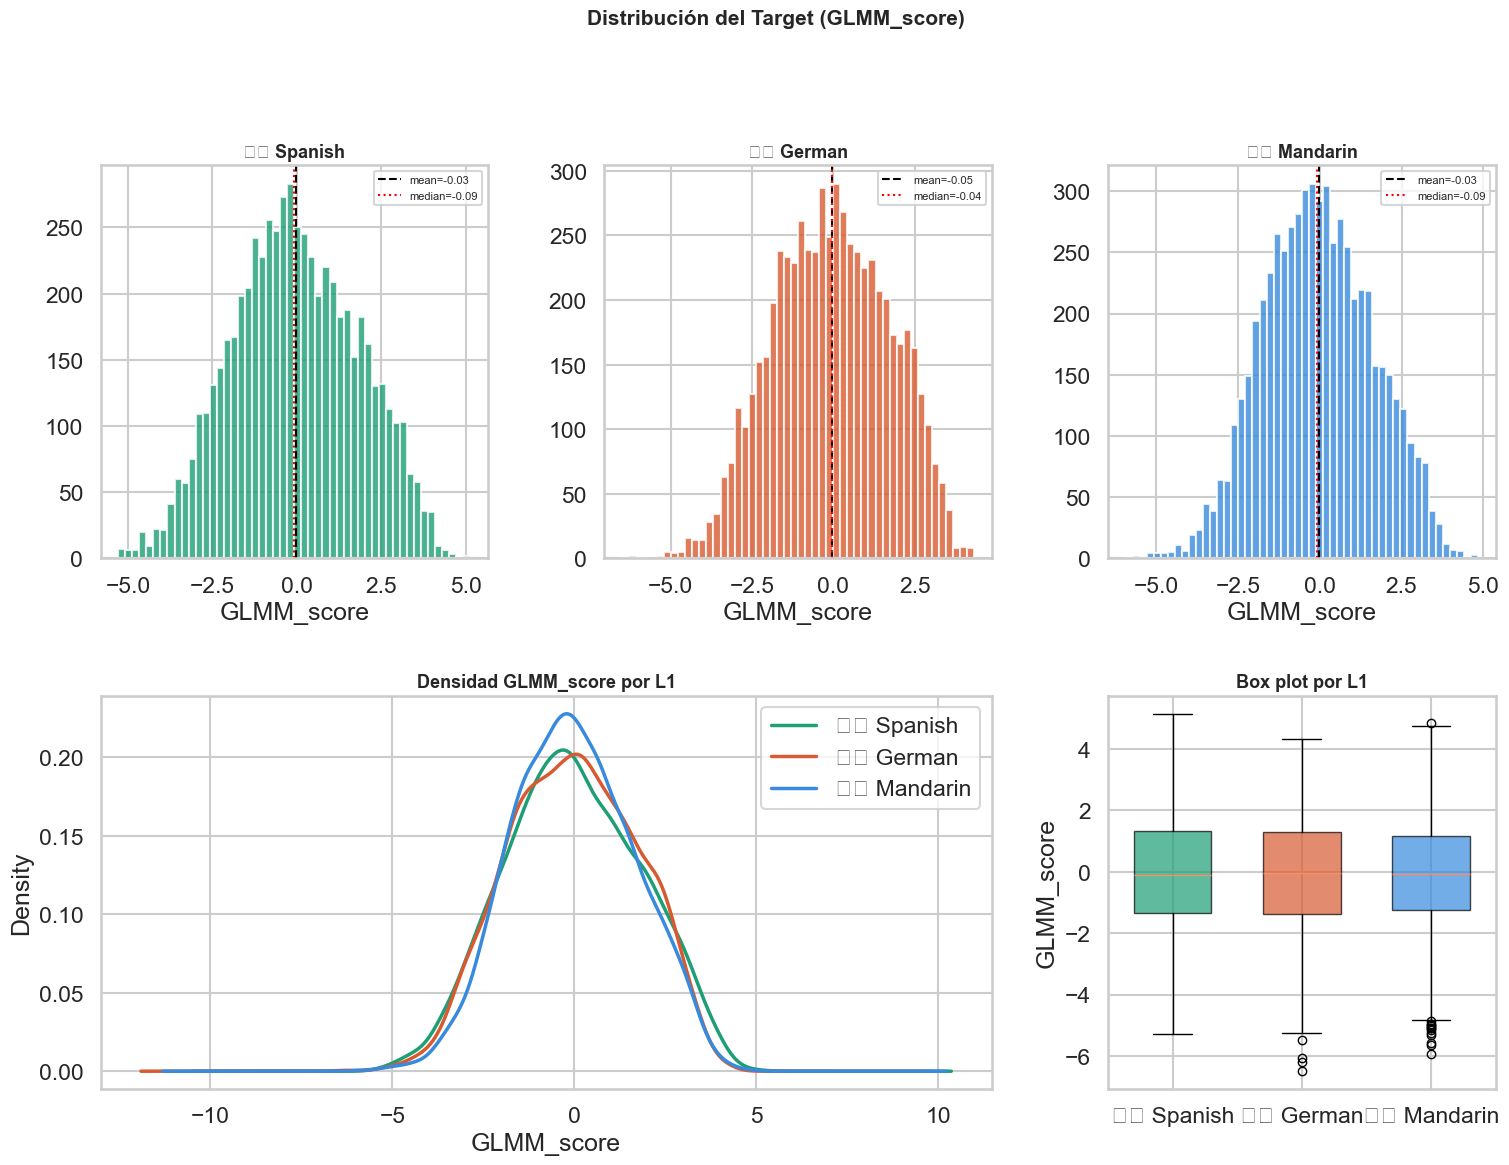

Estadísticas descriptivas por L1:


,count,mean,std,min,25%,50%,75%,max
L1,,,,,,,,
cn,6091.0,-0.034,1.668,-5.931,-1.245,-0.087,1.157,4.835
de,6091.0,-0.051,1.770,-6.498,-1.363,-0.040,1.278,4.323
es,6091.0,-0.032,1.862,-5.286,-1.347,-0.094,1.331,5.143



Media GLMM_score — Train vs Dev:
  🇪🇸 Spanish: train=-0.032 | dev=0.035 | diff=+0.066
  🇩🇪 German: train=-0.051 | dev=-0.092 | diff=-0.041
  🇨🇳 Mandarin: train=-0.034 | dev=0.072 | diff=+0.106


In [ ]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

# Row 1: Histograms by L1
for i, l1 in enumerate(L1S):
    ax = fig.add_subplot(gs[0, i])
    subset = train[train["L1"] == l1]
    ax.hist(subset[TARGET], bins=50, color=L1_COLORS[l1], edgecolor="white", alpha=0.8)
    ax.axvline(subset[TARGET].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={subset[TARGET].mean():.2f}")
    ax.axvline(subset[TARGET].median(), color="red", linestyle=":", linewidth=1.5,
               label=f"median={subset[TARGET].median():.2f}")
    ax.set_title(f"{L1_LABELS[l1]}", fontsize=13, fontweight="bold")
    ax.set_xlabel(TARGET)
    ax.legend(fontsize=8)

# Row 2: KDE overlay + Box plots
ax_kde = fig.add_subplot(gs[1, 0:2])
for l1 in L1S:
    subset = train[train["L1"] == l1]
    subset[TARGET].plot.kde(ax=ax_kde, label=L1_LABELS[l1], color=L1_COLORS[l1], linewidth=2.5)
ax_kde.set_title("GLMM_score density by L1", fontsize=13, fontweight="bold")
ax_kde.set_xlabel(TARGET)
ax_kde.legend()

ax_box = fig.add_subplot(gs[1, 2])
colors = [L1_COLORS[l1] for l1 in L1S]
bp = ax_box.boxplot([train[train["L1"] == l1][TARGET].values for l1 in L1S],
                     labels=[L1_LABELS[l1] for l1 in L1S], patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax_box.set_title("Box plot by L1", fontsize=13, fontweight="bold")
ax_box.set_ylabel(TARGET)

plt.suptitle("Target Distribution (GLMM_score)", fontsize=15, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats
print("Descriptive statistics by L1:")
display(train.groupby("L1")[TARGET].describe().round(3))

# Train vs Dev shift
print("\nGLMM_score mean - Train vs Dev:")
for l1 in L1S:
    tr_mean = train[train["L1"] == l1][TARGET].mean()
    dv_mean = dev[dev["L1"] == l1][TARGET].mean()
    print(f"  {L1_LABELS[l1]}: train={tr_mean:.3f} | dev={dv_mean:.3f} | diff={dv_mean-tr_mean:+.3f}")


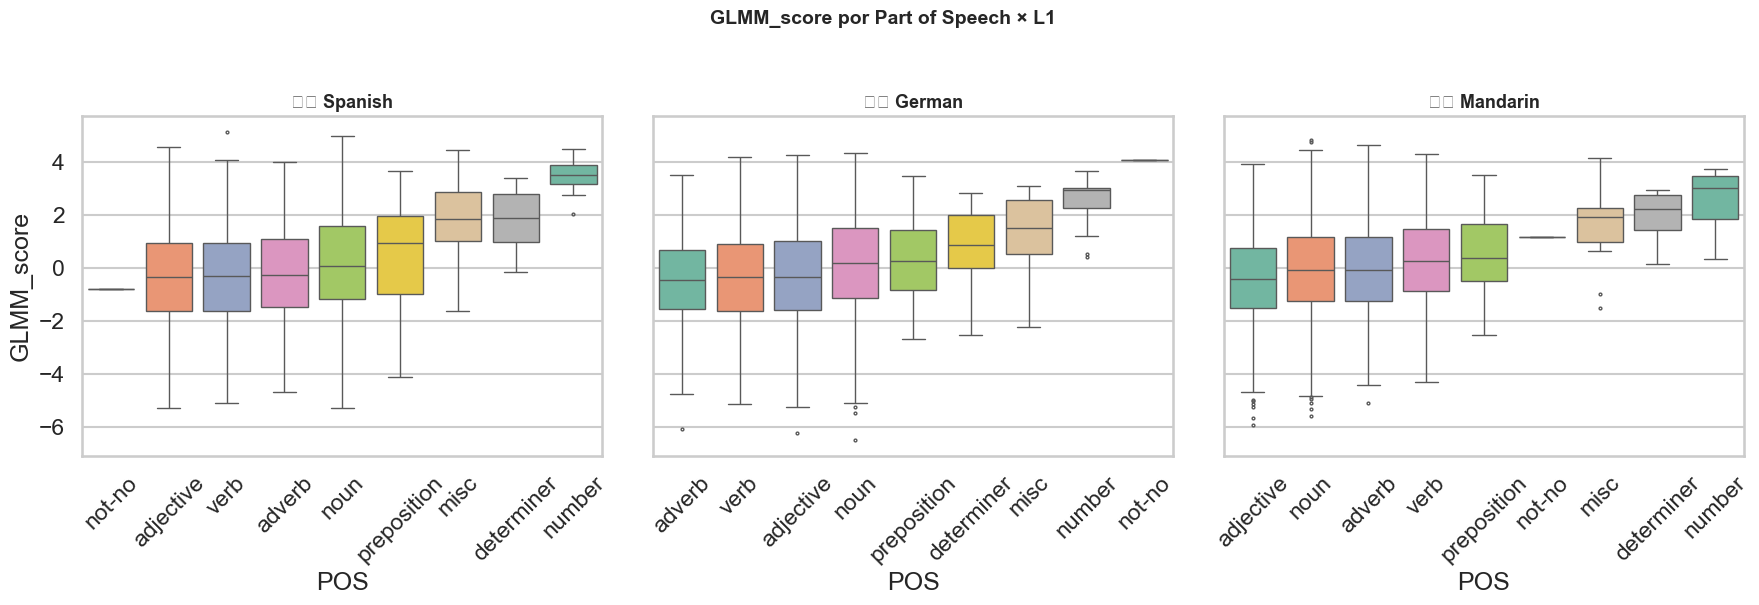

In [ ]:
# POS x GLMM_score
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, l1 in zip(axes, L1S):
    subset = train[train["L1"] == l1]
    order = subset.groupby("en_target_pos")[TARGET].median().sort_values().index
    sns.boxplot(data=subset, x="en_target_pos", y=TARGET, order=order,
                ax=ax, palette="Set2", fliersize=2)
    ax.set_title(f"{L1_LABELS[l1]}", fontsize=13, fontweight="bold")
    ax.set_xlabel("POS")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("GLMM_score by Part of Speech x L1", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_pos_target.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Feature Engineering - 22 Linguistic Features

### Categories:
| Category | Features | Source |
|----------|----------|--------|
| **Orthography** | word_length, clue_ratio | Direct text |
| **Phonology** | n_phonemes, silent_letters, n_consonant_clusters, max_cluster_length, final_cluster_size, r_count, has_r, spelling_phoneme_ratio | CMU Dict |
| **L1 Phonology** | difficult_phonemes, difficult_phoneme_ratio, unfamiliar_letters, has_unfamiliar | PHOIBLE |
| **Semantics** | polysemy_pos, polysemy_all, is_homonym, homonym_pos_count, word_frequency | WordNet |
| **L1↔EN Distance** | cosine_dist_l1_en, levenshtein_dist | Character n-grams |
| **Morphology** | morphological_complexity | Prefix/suffix rules |


In [ ]:
CMU_DICT = cmudict.dict()
POS_MAP = {"noun": wn.NOUN, "verb": wn.VERB, "adjective": wn.ADJ, "adverb": wn.ADV}

L1_ABSENT_PHONEMES = {
    "es": {"TH", "DH", "SH", "ZH", "V", "Z"},
    "de": {"TH", "DH"},
    "cn": {"TH", "DH", "SH", "ZH", "R", "V", "Z", "NG"},
}
L1_UNFAMILIAR_LETTERS = {"es": set("wk"), "de": set(), "cn": set()}
PREFIXES = ["un", "re", "in", "im", "ir", "il", "dis", "en", "em",
            "non", "pre", "mis", "over", "under", "out", "sub", "super"]
SUFFIXES = ["ing", "tion", "sion", "ment", "ness", "able", "ible", "ful",
            "less", "ous", "ive", "al", "ly", "er", "est", "ed", "es", "s"]

@lru_cache(maxsize=None)
def get_synsets(word):
    return wn.synsets(str(word).lower(), lang="eng")

@lru_cache(maxsize=None)
def get_pronunciation(word):
    return CMU_DICT.get(str(word).lower(), [[]])[0]

def polysemy_pos(word, pos):
    wn_pos = POS_MAP.get(str(pos).lower())
    return len(wn.synsets(str(word).lower(), pos=wn_pos, lang="eng")) if wn_pos else len(get_synsets(word))

def is_homonym(word): return int(len({s.pos() for s in get_synsets(word)}) > 1)
def consonant_cluster_count(word): return len(re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower()))
def r_count(word):
    pron = get_pronunciation(word)
    return sum(1 for p in pron if p.startswith("R")) if pron else str(word).lower().count("r")
def has_r(word): return int("r" in str(word).lower())
def phoneme_count(word):
    pron = get_pronunciation(word)
    return len(pron) if pron else max(len(re.findall(r"[aeiouy]+", str(word).lower())) * 2, 1)
def silent_letter_count(word): return max(len(str(word)) - phoneme_count(word), 0)
def difficult_phoneme_count(word, l1):
    pron = get_pronunciation(word)
    absent = L1_ABSENT_PHONEMES.get(l1, set())
    if not pron or not absent: return 0
    return sum(1 for p in [re.sub(r"\d", "", ph) for ph in pron] if p in absent)
def difficult_phoneme_ratio(word, l1):
    n = phoneme_count(word)
    return difficult_phoneme_count(word, l1) / n if n > 0 else 0.0
def wordnet_frequency(word):
    total = 0
    for syn in get_synsets(word):
        for lem in syn.lemmas():
            if lem.name().lower() == str(word).lower(): total += lem.count()
    return math.log1p(total)
def polysemy_all(word): return len(get_synsets(word))
def homonym_pos_count(word): return len({s.pos() for s in get_synsets(word)})
def max_cluster_length(word):
    clusters = re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower())
    return max((len(c) for c in clusters), default=0)
def spelling_phoneme_ratio(word): return len(str(word)) / max(phoneme_count(word), 1)
def unfamiliar_letter_count(word, l1):
    return sum(1 for ch in str(word).lower() if ch in L1_UNFAMILIAR_LETTERS.get(l1, set()))
def has_unfamiliar(word, l1): return int(unfamiliar_letter_count(word, l1) > 0)
def char_ngram_distance(w1, w2, n=2):
    def ng(w): w=str(w).lower(); return set(w[i:i+n] for i in range(len(w)-n+1)) if len(w)>=n else {w}
    s1, s2 = ng(w1), ng(w2); u = len(s1|s2)
    return 1.0 - (len(s1&s2)/u) if u>0 else 1.0
def normalized_levenshtein(w1, w2):
    s1, s2 = str(w1).lower(), str(w2).lower()
    if len(s1)<len(s2): s1,s2=s2,s1
    if not s2: return float(len(s1))/max(len(s1),1)
    prev=list(range(len(s2)+1))
    for i,c1 in enumerate(s1):
        curr=[i+1]
        for j,c2 in enumerate(s2): curr.append(min(prev[j+1]+1,curr[j]+1,prev[j]+(c1!=c2)))
        prev=curr
    return prev[-1]/max(len(s1),len(s2))
def morphological_complexity(word):
    w=str(word).lower(); count=0
    for p in PREFIXES:
        if w.startswith(p) and len(w)>len(p)+2: count+=1; break
    for s in sorted(SUFFIXES,key=len,reverse=True):
        if w.endswith(s) and len(w)>len(s)+2: count+=1; break
    return count
def final_cluster_size(word):
    m=re.search(r"[bcdfghjklmnpqrstvwxyz]+$",str(word).lower())
    return len(m.group()) if m else 0

def add_features(df):
    d = df.copy(); w = "en_target_word"
    d["word_length"] = d[w].astype(str).str.len()
    d["clue_blanks"] = d["en_target_clue"].astype(str).str.count("_")
    d["clue_ratio"] = d["clue_blanks"] / d["word_length"].clip(lower=1)
    d["polysemy_pos"] = d.apply(lambda r: polysemy_pos(r[w], r["en_target_pos"]), axis=1)
    d["is_homonym"] = d[w].apply(is_homonym)
    d["n_consonant_clusters"] = d[w].apply(consonant_cluster_count)
    d["r_count"] = d[w].apply(r_count)
    d["has_r"] = d[w].apply(has_r)
    d["n_phonemes"] = d[w].apply(phoneme_count)
    d["silent_letters"] = d[w].apply(silent_letter_count)
    d["difficult_phonemes"] = d.apply(lambda r: difficult_phoneme_count(r[w], r["L1"]), axis=1)
    d["difficult_phoneme_ratio"] = d.apply(lambda r: difficult_phoneme_ratio(r[w], r["L1"]), axis=1)
    d["word_frequency"] = d[w].apply(wordnet_frequency)
    d["polysemy_all"] = d[w].apply(polysemy_all)
    d["homonym_pos_count"] = d[w].apply(homonym_pos_count)
    d["max_cluster_length"] = d[w].apply(max_cluster_length)
    d["spelling_phoneme_ratio"] = d[w].apply(spelling_phoneme_ratio)
    d["unfamiliar_letters"] = d.apply(lambda r: unfamiliar_letter_count(r[w], r["L1"]), axis=1)
    d["has_unfamiliar"] = d.apply(lambda r: has_unfamiliar(r[w], r["L1"]), axis=1)
    d["cosine_dist_l1_en"] = d.apply(lambda r: char_ngram_distance(r["L1_source_word"], r[w]), axis=1)
    d["levenshtein_dist"] = d.apply(lambda r: normalized_levenshtein(r["L1_source_word"], r[w]), axis=1)
    d["morphological_complexity"] = d[w].apply(morphological_complexity)
    d["final_cluster_size"] = d[w].apply(final_cluster_size)
    return d

FEATURE_COLS = [
    "word_length", "clue_ratio", "polysemy_pos", "is_homonym",
    "n_consonant_clusters", "r_count", "has_r", "n_phonemes", "silent_letters",
    "difficult_phonemes", "difficult_phoneme_ratio", "word_frequency",
    "polysemy_all", "homonym_pos_count", "max_cluster_length",
    "spelling_phoneme_ratio", "unfamiliar_letters", "has_unfamiliar",
    "cosine_dist_l1_en", "levenshtein_dist", "morphological_complexity",
    "final_cluster_size",
]

print("Generating 22 features for train...")
train_feat = add_features(train)
print("Generating 22 features for dev...")
dev_feat = add_features(dev)
print(f"\nDone: {len(FEATURE_COLS)} features generated")
print(f"train_feat: {train_feat.shape} | dev_feat: {dev_feat.shape}")


Generando 22 features para train...
Generando 22 features para dev...

✓ 22 features generadas
train_feat: (18273, 32) | dev_feat: (2031, 32)


## 4. Feature Distributions

Histogram of each feature + normality test (D'Agostino-Pearson).
Many linguistic features are skewed; this is expected.


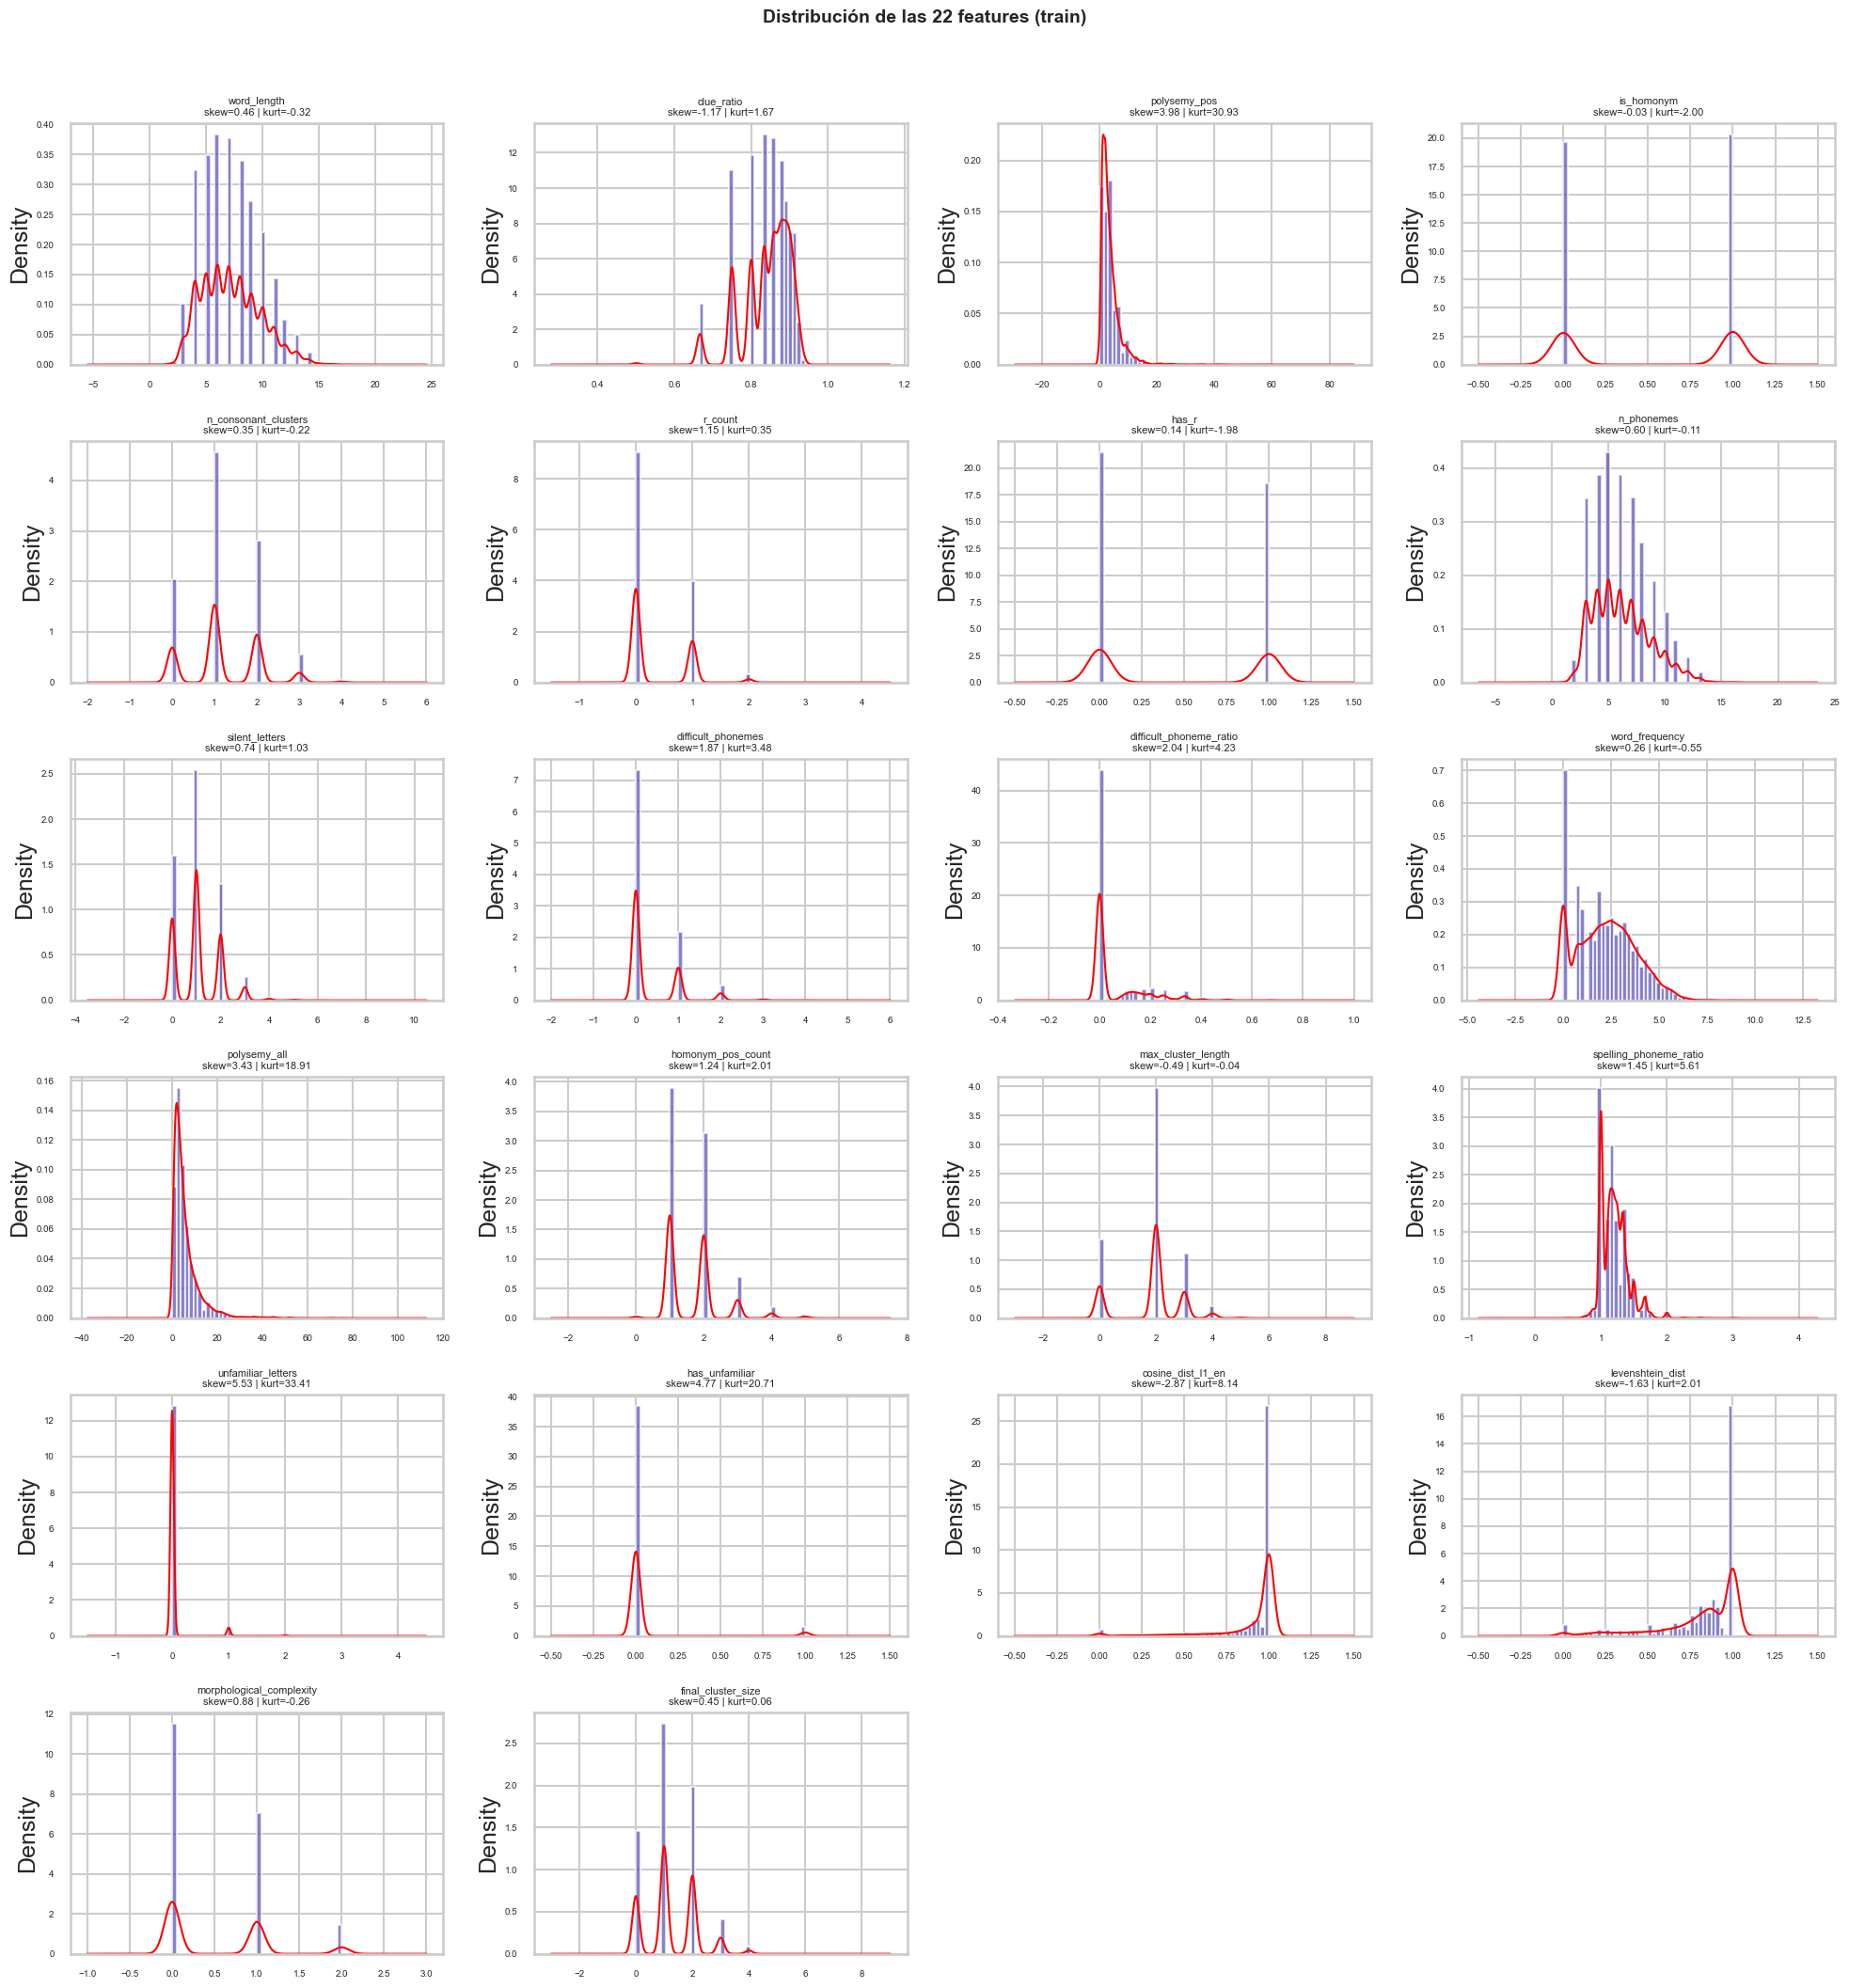

Test de normalidad (D'Agostino-Pearson):
  ✗ = no normal (p < 0.05) | ✓ = normal


,feature,skew,kurtosis,p_value,normal
1,clue_ratio,-1.1704,1.6717,0.0,✗
2,polysemy_pos,3.9767,30.9328,0.0,✗
3,is_homonym,-0.0305,-1.9993,0.0,✗
5,r_count,1.1522,0.3549,0.0,✗
6,has_r,0.1432,-1.9797,0.0,✗
10,difficult_phoneme_ratio,2.0432,4.2321,0.0,✗
9,difficult_phonemes,1.8658,3.4769,0.0,✗
8,silent_letters,0.7367,1.0323,0.0,✗
15,spelling_phoneme_ratio,1.4487,5.6054,0.0,✗
13,homonym_pos_count,1.2356,2.0131,0.0,✗


In [ ]:
n_feats = len(FEATURE_COLS)
n_cols = 4
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()

normality_results = []

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    vals = train_feat[feat].dropna()

    # Histogram with KDE
    ax.hist(vals, bins=40, color="#534AB7", alpha=0.7, edgecolor="white", density=True)
    try:
        vals.plot.kde(ax=ax, color="red", linewidth=1.5)
    except:
        pass

    # Normality test
    try:
        stat, p = normaltest(vals)
        is_normal = "yes" if p > 0.05 else "no"
        normality_results.append({"feature": feat, "statistic": stat, "p_value": p,
                                   "normal": is_normal, "skew": vals.skew(), "kurtosis": vals.kurtosis()})
    except:
        normality_results.append({"feature": feat, "statistic": np.nan, "p_value": np.nan,
                                   "normal": "unknown", "skew": vals.skew(), "kurtosis": vals.kurtosis()})

    ax.set_title(f"{feat}\nskew={vals.skew():.2f} | kurt={vals.kurtosis():.2f}", fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of the 22 features (train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Normality table
norm_df = pd.DataFrame(normality_results).sort_values("p_value")
print("Normality test (D'Agostino-Pearson):")
print("  no = not normal (p < 0.05) | yes = normal")
display(norm_df[["feature", "skew", "kurtosis", "p_value", "normal"]].round(4))


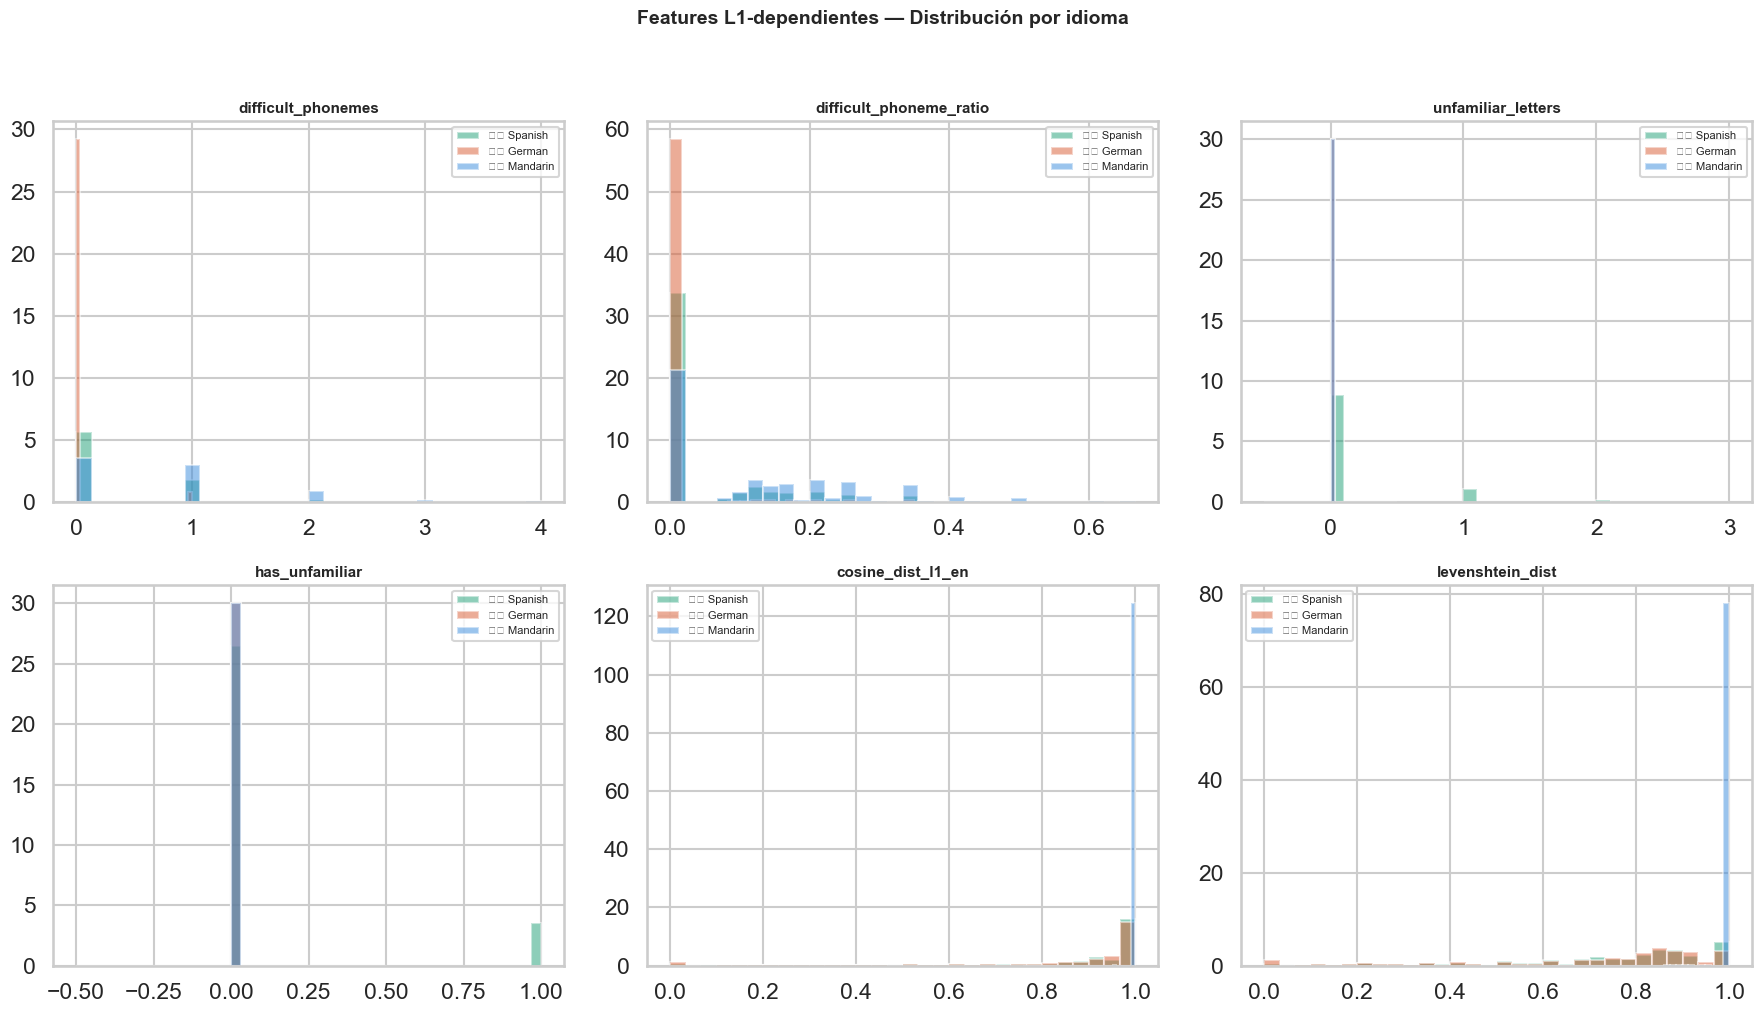


Estadísticas de features L1-dependientes:

  difficult_phonemes:
    🇪🇸 Spanish: mean=0.276 std=0.501 zero%=74.8%
    🇩🇪 German: mean=0.027 std=0.161 zero%=97.3%
    🇨🇳 Mandarin: mean=0.682 std=0.752 zero%=47.2%

  difficult_phoneme_ratio:
    🇪🇸 Spanish: mean=0.044 std=0.086 zero%=74.8%
    🇩🇪 German: mean=0.005 std=0.035 zero%=97.3%
    🇨🇳 Mandarin: mean=0.112 std=0.130 zero%=47.2%

  unfamiliar_letters:
    🇪🇸 Spanish: mean=0.127 std=0.362 zero%=88.3%
    🇩🇪 German: mean=0.000 std=0.000 zero%=100.0%
    🇨🇳 Mandarin: mean=0.000 std=0.000 zero%=100.0%

  has_unfamiliar:
    🇪🇸 Spanish: mean=0.117 std=0.321 zero%=88.3%
    🇩🇪 German: mean=0.000 std=0.000 zero%=100.0%
    🇨🇳 Mandarin: mean=0.000 std=0.000 zero%=100.0%

  cosine_dist_l1_en:
    🇪🇸 Spanish: mean=0.874 std=0.214 zero%=1.4%
    🇩🇪 German: mean=0.849 std=0.259 zero%=4.4%
    🇨🇳 Mandarin: mean=1.000 std=0.008 zero%=0.0%

  levenshtein_dist:
    🇪🇸 Spanish: mean=0.733 std=0.243 zero%=1.3%
    🇩🇪 German: mean=0.712 std=0.267 z

In [ ]:
# L1-dependent features
l1_features = ["difficult_phonemes", "difficult_phoneme_ratio",
               "unfamiliar_letters", "has_unfamiliar",
               "cosine_dist_l1_en", "levenshtein_dist"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(l1_features):
    ax = axes[i]
    for l1 in L1S:
        vals = train_feat[train_feat["L1"] == l1][feat].dropna()
        ax.hist(vals, bins=30, alpha=0.5, color=L1_COLORS[l1], label=L1_LABELS[l1], density=True)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("L1-dependent features - Distribution by language", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_l1_dependent_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nStatistics for L1-dependent features:")
for feat in l1_features:
    print(f"\n  {feat}:")
    for l1 in L1S:
        vals = train_feat[train_feat["L1"] == l1][feat]
        print(f"    {L1_LABELS[l1]}: mean={vals.mean():.3f} std={vals.std():.3f} "
              f"zero%={100*(vals==0).mean():.1f}%")


## 5. Feature Correlation with GLMM_score

Pearson (linear) and Spearman (monotonic), by L1 and globally.


In [ ]:
def full_correlation_table(df, features, target):
    rows = []
    for feat in features:
        row = {"feature": feat}
        valid = df[[feat, target]].dropna()
        if len(valid) > 2 and valid[feat].std() > 0:
            row["pearson_global"] = pearsonr(valid[feat], valid[target])[0]
            row["spearman_global"] = spearmanr(valid[feat], valid[target])[0]
        for l1 in L1S:
            sub = df[df["L1"] == l1][[feat, target]].dropna()
            if len(sub) > 2 and sub[feat].std() > 0:
                row[f"pearson_{l1}"] = pearsonr(sub[feat], sub[target])[0]
                row[f"spearman_{l1}"] = spearmanr(sub[feat], sub[target])[0]
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")

corr_df = full_correlation_table(train_feat, FEATURE_COLS, TARGET)
corr_df["abs_pearson"] = corr_df["pearson_global"].abs()
corr_df = corr_df.sort_values("abs_pearson", ascending=False)

print("=" * 75)
print("  CORRELATION WITH GLMM_score (Pearson)")
print("=" * 75)
display(corr_df[["pearson_global", "pearson_es", "pearson_de", "pearson_cn"]]
    .style.format("{:.3f}", na_rep="-")
    .background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4))


═══════════════════════════════════════════════════════════════════════════
  CORRELACIÓN CON GLMM_score (Pearson)
═══════════════════════════════════════════════════════════════════════════


,pearson_global,pearson_es,pearson_de,pearson_cn
feature,,,,
clue_ratio,-0.381,-0.350,-0.353,-0.449
word_length,-0.369,-0.328,-0.344,-0.441
n_phonemes,-0.353,-0.304,-0.326,-0.437
word_frequency,0.314,0.237,0.233,0.488
cosine_dist_l1_en,-0.246,-0.271,-0.352,0.060
n_consonant_clusters,-0.243,-0.251,-0.220,-0.260
morphological_complexity,-0.237,-0.243,-0.236,-0.232
levenshtein_dist,-0.216,-0.245,-0.368,0.067
polysemy_pos,0.187,0.147,0.152,0.268


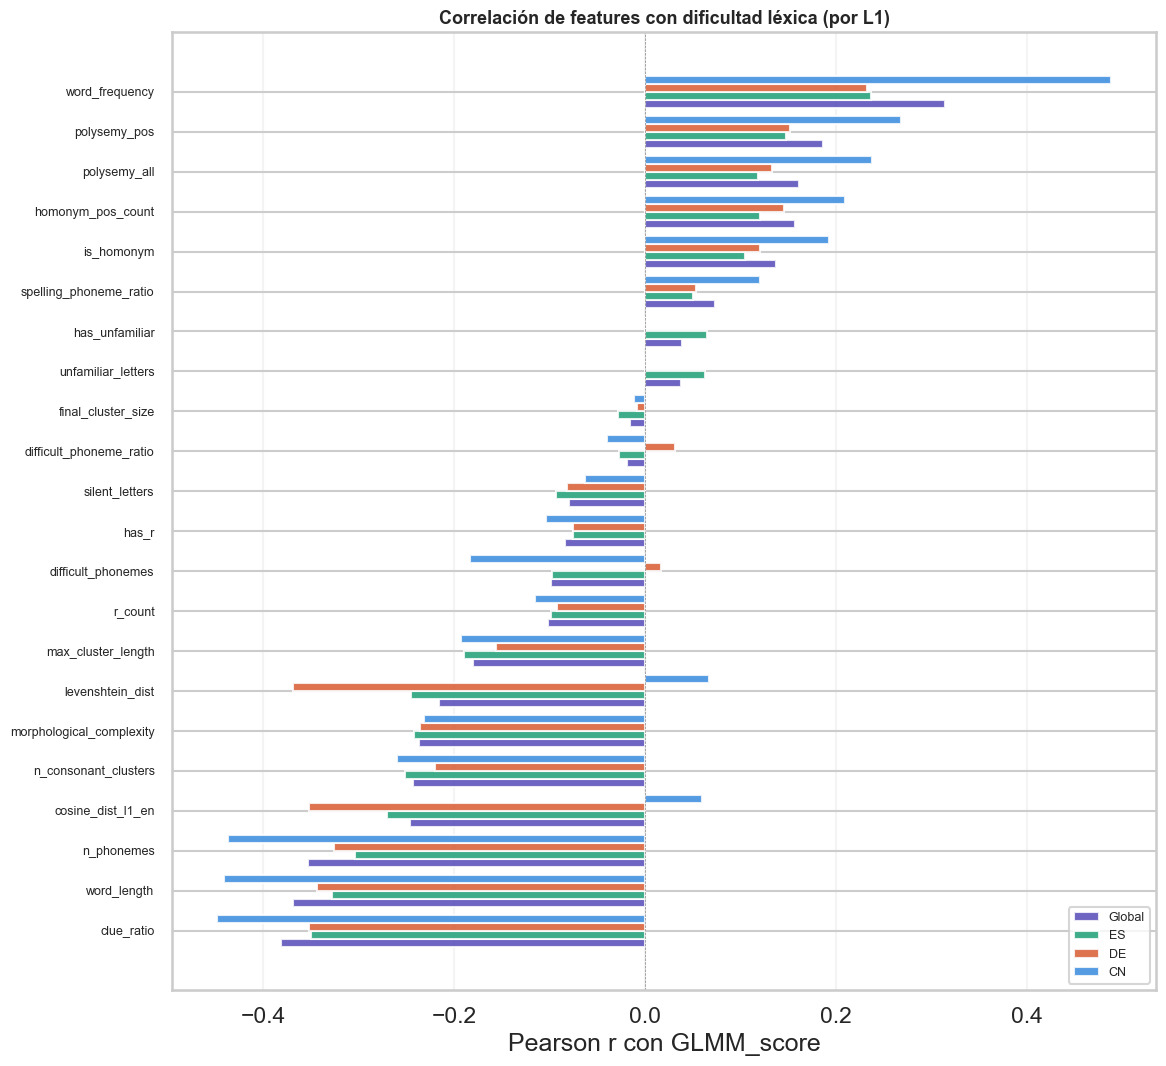

In [ ]:
# Bar chart: correlation by feature x L1
plot_corr = corr_df[["pearson_global", "pearson_es", "pearson_de", "pearson_cn"]].sort_values("pearson_global")

fig, ax = plt.subplots(figsize=(12, max(len(FEATURE_COLS) * 0.5, 6)))
x = np.arange(len(plot_corr))
bar_h = 0.2

for i, (col, color, label) in enumerate([
    ("pearson_global", "#534AB7", "Global"),
    ("pearson_es", "#1D9E75", "ES"),
    ("pearson_de", "#D85A30", "DE"),
    ("pearson_cn", "#378ADD", "CN"),
]):
    vals = plot_corr[col].fillna(0)
    ax.barh(x + i * bar_h, vals, height=bar_h, label=label, color=color, alpha=0.85)

ax.set_yticks(x + bar_h * 1.5)
ax.set_yticklabels(plot_corr.index, fontsize=9)
ax.set_xlabel("Pearson r with GLMM_score")
ax.set_title("Feature correlation with lexical difficulty (by L1)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()


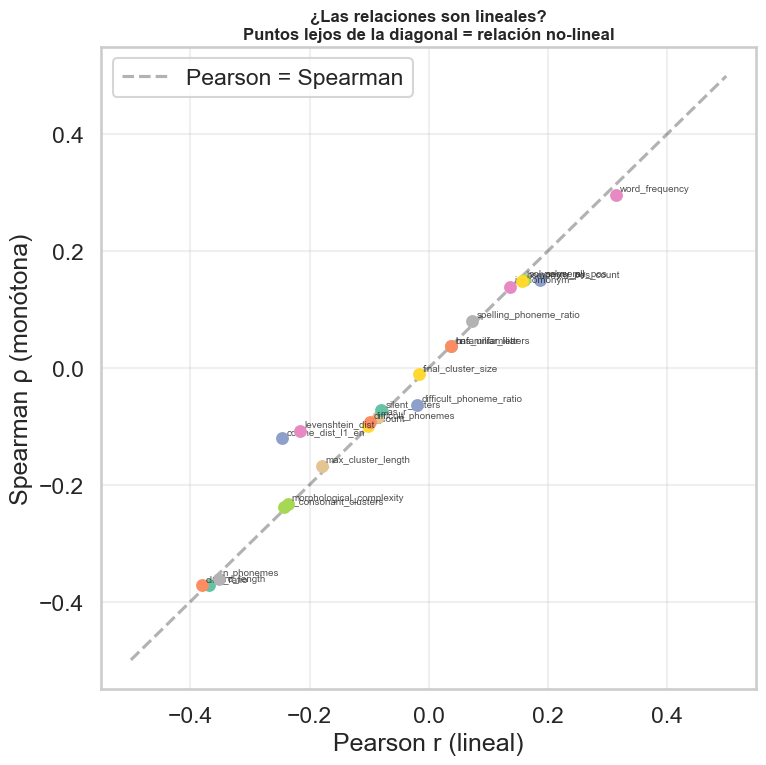

Features con mayor ganancia Spearman vs Pearson (relación no-lineal):
  difficult_phoneme_ratio: Δ = +0.045 (Pearson=-0.019, Spearman=-0.064)
  n_phonemes: Δ = +0.008 (Pearson=-0.353, Spearman=-0.361)
  spelling_phoneme_ratio: Δ = +0.008 (Pearson=0.073, Spearman=0.081)
  word_length: Δ = +0.003 (Pearson=-0.369, Spearman=-0.372)
  is_homonym: Δ = +0.002 (Pearson=0.137, Spearman=0.139)


In [ ]:
# Are relationships linear? Pearson vs Spearman comparison
fig, ax = plt.subplots(figsize=(8, 8))

for feat in FEATURE_COLS:
    p = corr_df.loc[feat, "pearson_global"] if feat in corr_df.index else 0
    s = corr_df.loc[feat, "spearman_global"] if feat in corr_df.index else 0
    if pd.notna(p) and pd.notna(s):
        ax.scatter(p, s, s=60, zorder=3)
        ax.annotate(feat, (p, s), fontsize=7, alpha=0.8,
                    xytext=(3, 3), textcoords="offset points")

ax.plot([-0.5, 0.5], [-0.5, 0.5], "k--", alpha=0.3, label="Pearson = Spearman")
ax.set_xlabel("Pearson r (linear)")
ax.set_ylabel("Spearman rho (monotonic)")
ax.set_title("Are relationships linear?\nPoints far from diagonal indicate non-linearity",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_pearson_vs_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

# Identify features with largest difference
diff = (corr_df["spearman_global"].abs() - corr_df["pearson_global"].abs()).dropna()
diff = diff.sort_values(ascending=False)
print("Features with largest Spearman gain over Pearson (non-linear behavior):")
for feat, d in diff.head(5).items():
    print(f"  {feat}: delta = {d:+.3f} (Pearson={corr_df.loc[feat, 'pearson_global']:.3f}, "
          f"Spearman={corr_df.loc[feat, 'spearman_global']:.3f})")


## 6. Multicollinearity Across Features

Inter-feature correlation heatmap.
Features with |r| > 0.85 are candidates for removal (redundant).


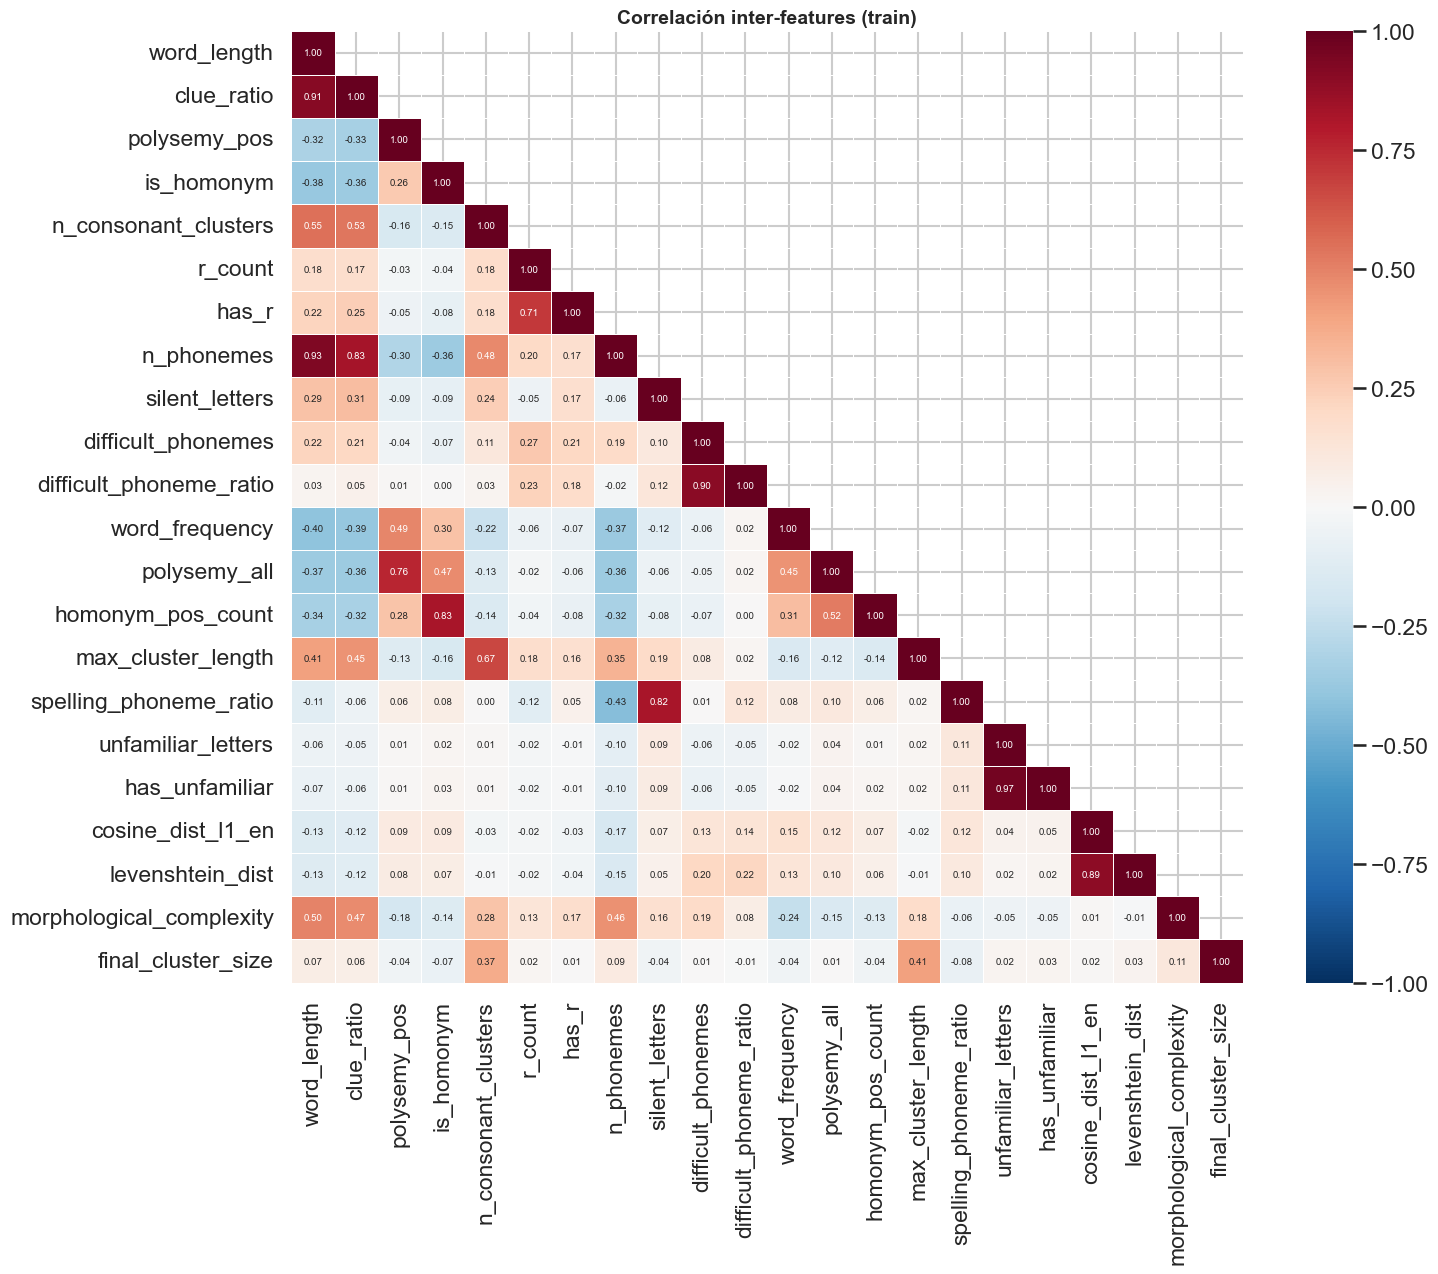

Pares con |r| > 0.85:


,feature_1,feature_2,r
0,word_length,clue_ratio,0.909
1,word_length,n_phonemes,0.933
2,difficult_phonemes,difficult_phoneme_ratio,0.902
3,unfamiliar_letters,has_unfamiliar,0.966
4,cosine_dist_l1_en,levenshtein_dist,0.892


In [ ]:
inter_corr = train_feat[FEATURE_COLS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(inter_corr, dtype=bool), k=1)
sns.heatmap(inter_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Inter-feature correlation (train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_multicollinearity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Highly correlated pairs
THRESHOLD = 0.85
high_corr = []
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        r = inter_corr.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr.append({
                "feature_1": FEATURE_COLS[i],
                "feature_2": FEATURE_COLS[j],
                "r": round(r, 3),
            })

if high_corr:
    print(f"Pairs with |r| > {THRESHOLD}:")
    display(pd.DataFrame(high_corr))
else:
    print(f"No pairs with |r| > {THRESHOLD}")


## 7. Automatic Feature Selection

Criterion: if two features have |r| > 0.85, we drop the one with lower
correlation with `GLMM_score`.


In [ ]:
to_remove = set()
log = []
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        f1, f2 = FEATURE_COLS[i], FEATURE_COLS[j]
        if f1 in to_remove and f2 in to_remove:
            continue
        r = inter_corr.loc[f1, f2]
        if abs(r) > THRESHOLD:
            r1 = abs(corr_df.loc[f1, "pearson_global"]) if f1 in corr_df.index else 0
            r2 = abs(corr_df.loc[f2, "pearson_global"]) if f2 in corr_df.index else 0
            drop = f2 if r1 >= r2 else f1
            keep = f1 if drop == f2 else f2
            if drop not in to_remove:
                to_remove.add(drop)
                log.append(f"drop {drop:30s} - redundant with {keep} (r={r:.3f})")

SELECTED_FEATURES = [f for f in FEATURE_COLS if f not in to_remove]

for entry in log:
    print(entry)
print(f"\nRemoved: {len(to_remove)} -> {sorted(to_remove)}")
print(f"Kept: {len(SELECTED_FEATURES)}")
print(f"\nFinal features: {SELECTED_FEATURES}")


🗑  word_length                    — redundante con clue_ratio (r=0.909)
🗑  n_phonemes                     — redundante con word_length (r=0.933)
🗑  difficult_phoneme_ratio        — redundante con difficult_phonemes (r=0.902)
🗑  unfamiliar_letters             — redundante con has_unfamiliar (r=0.966)
🗑  levenshtein_dist               — redundante con cosine_dist_l1_en (r=0.892)

Eliminadas: 5 → ['difficult_phoneme_ratio', 'levenshtein_dist', 'n_phonemes', 'unfamiliar_letters', 'word_length']
Conservadas: 17

Features finales: ['clue_ratio', 'polysemy_pos', 'is_homonym', 'n_consonant_clusters', 'r_count', 'has_r', 'silent_letters', 'difficult_phonemes', 'word_frequency', 'polysemy_all', 'homonym_pos_count', 'max_cluster_length', 'spelling_phoneme_ratio', 'has_unfamiliar', 'cosine_dist_l1_en', 'morphological_complexity', 'final_cluster_size']


## 8. Selected Features vs GLMM_score - Scatter Plots

Each point is colored by L1. Regression trend line per L1.


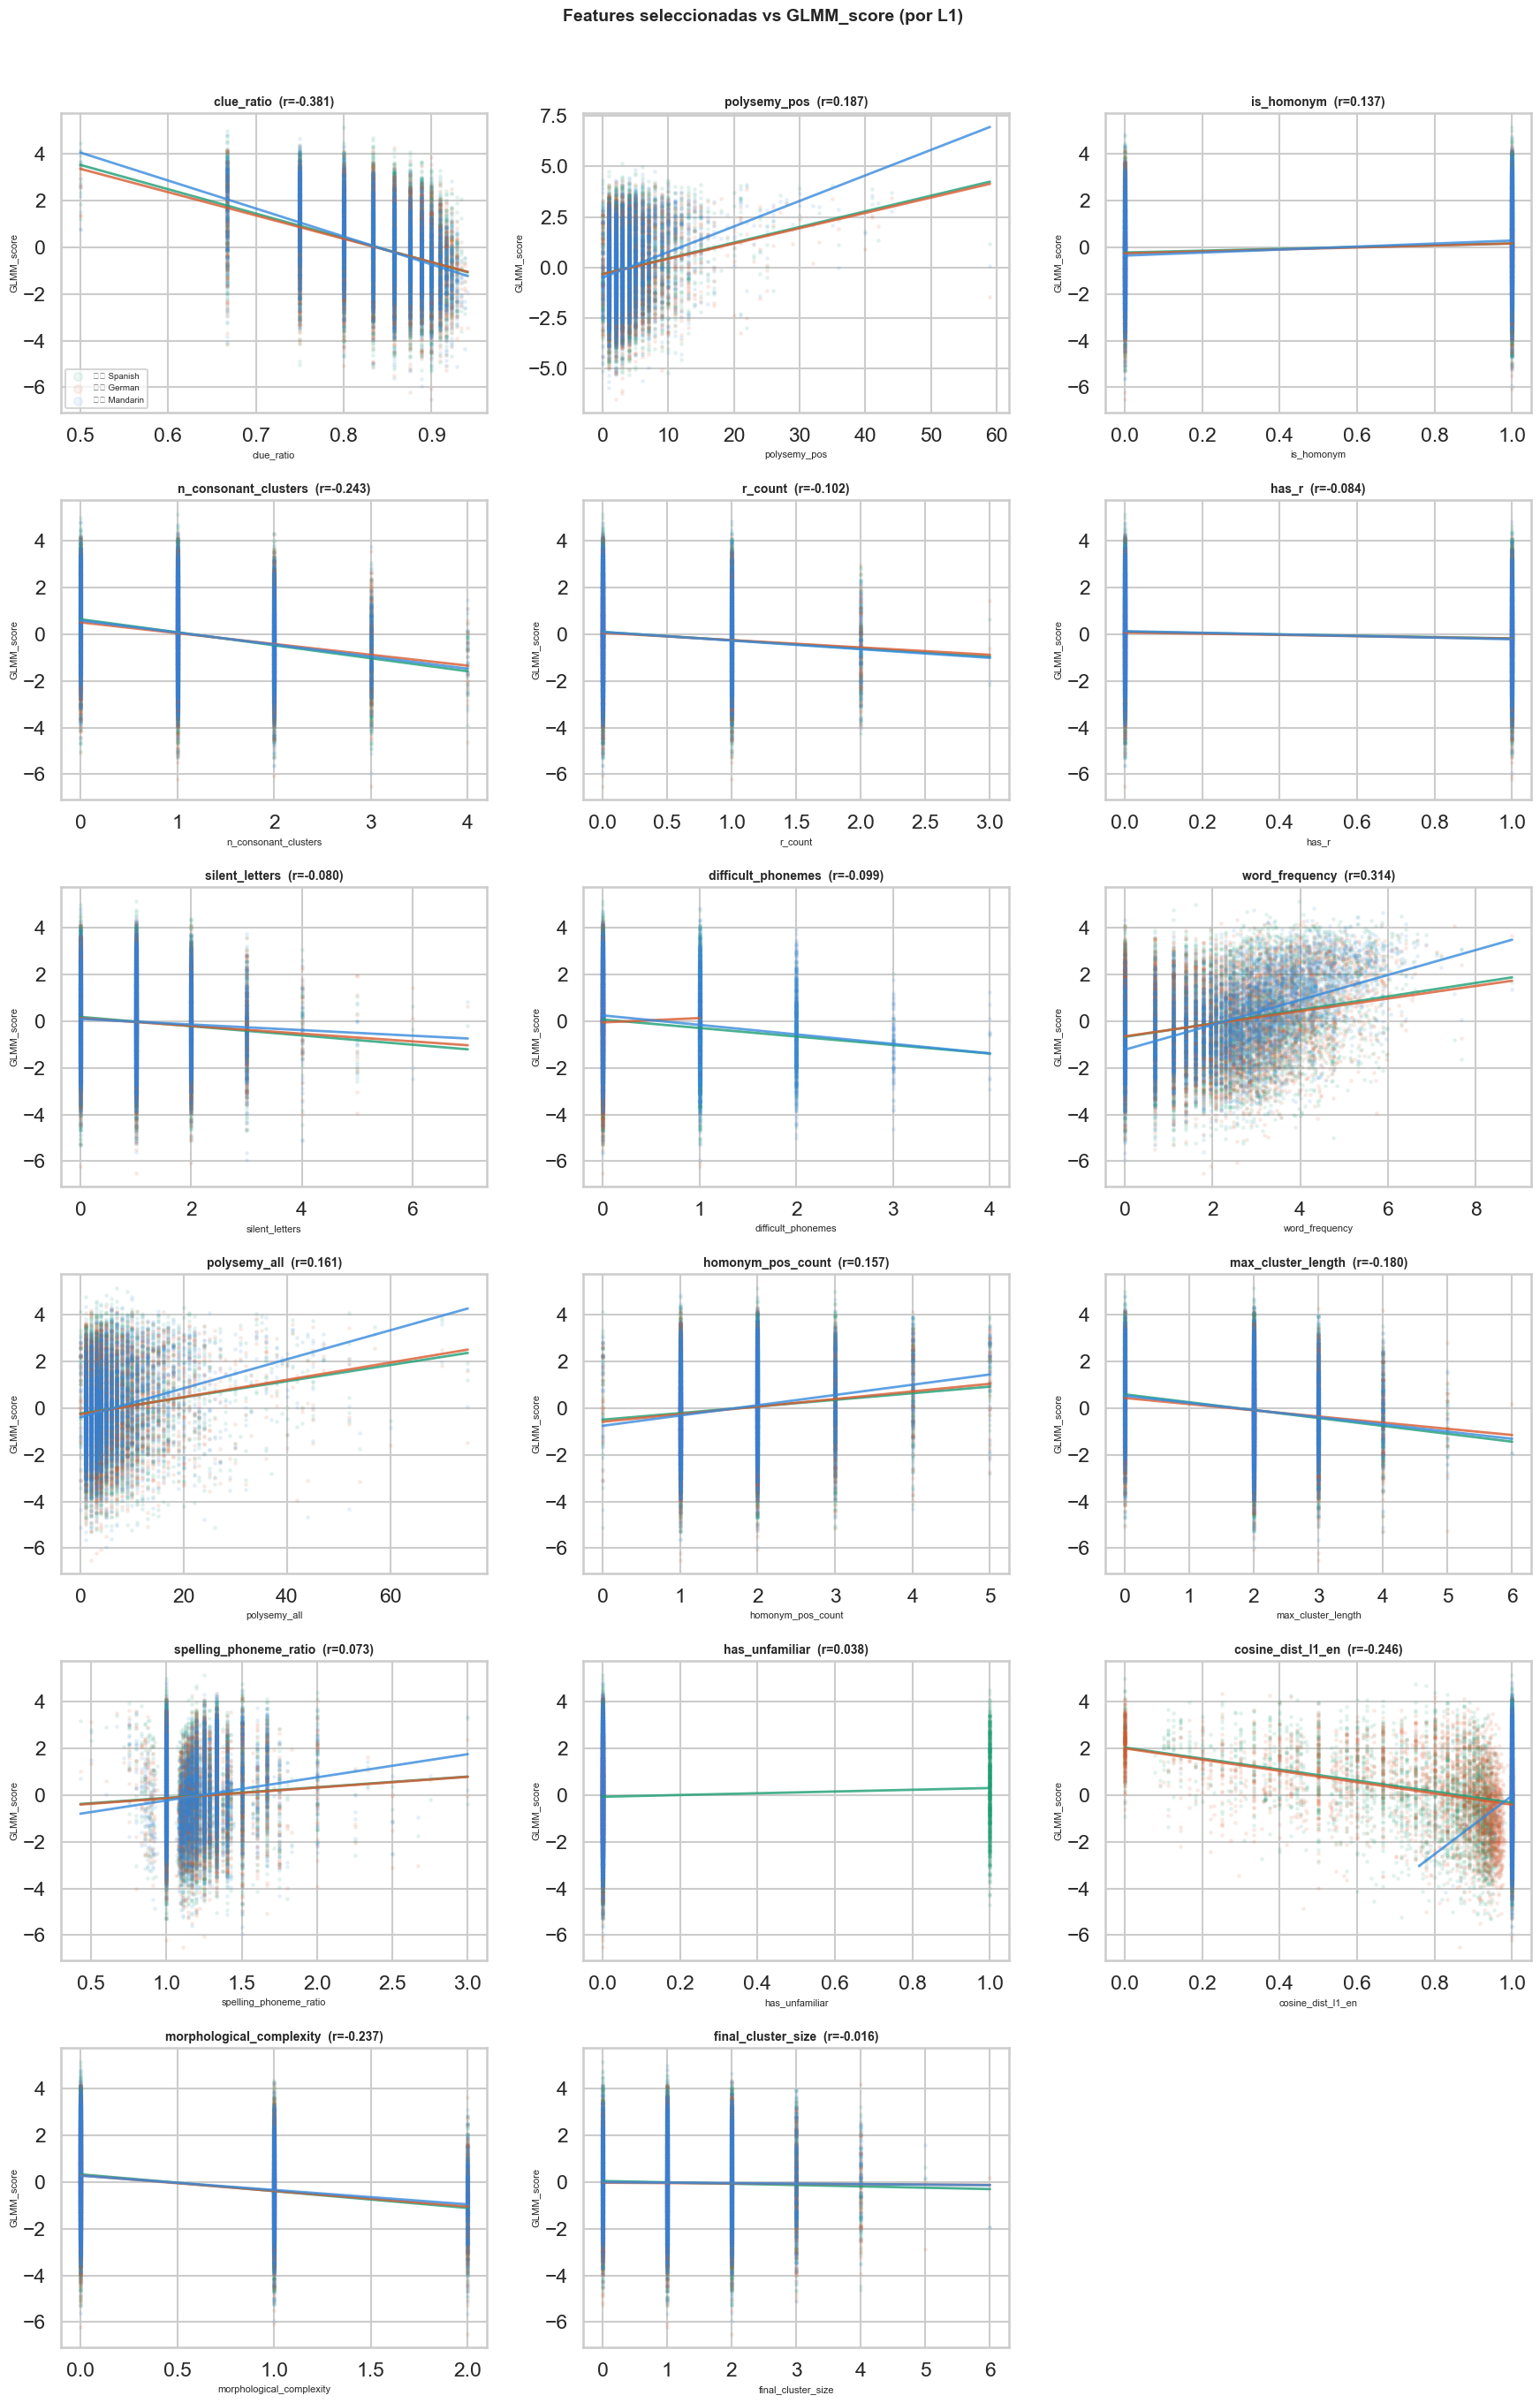

In [ ]:
n = len(SELECTED_FEATURES)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(SELECTED_FEATURES):
    ax = axes[i]
    for l1 in L1S:
        sub = train_feat[train_feat["L1"] == l1]
        ax.scatter(sub[feat], sub[TARGET], alpha=0.08, s=5,
                   color=L1_COLORS[l1], label=L1_LABELS[l1])
        # Trend line
        valid = sub[[feat, TARGET]].dropna()
        if len(valid) > 10 and valid[feat].std() > 0:
            z = np.polyfit(valid[feat], valid[TARGET], 1)
            x_range = np.linspace(valid[feat].min(), valid[feat].max(), 50)
            ax.plot(x_range, np.polyval(z, x_range), color=L1_COLORS[l1], linewidth=2, alpha=0.8)

    r_global = corr_df.loc[feat, "pearson_global"] if feat in corr_df.index else 0
    ax.set_title(f"{feat}  (r={r_global:.3f})", fontsize=10, fontweight="bold")
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    if i == 0:
        ax.legend(fontsize=7, markerscale=3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Selected features vs GLMM_score (by L1)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_selected_features_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. L1-specific Interactions

Do different features matter more for different languages?
Correlation heatmap by L1 highlights interaction effects.


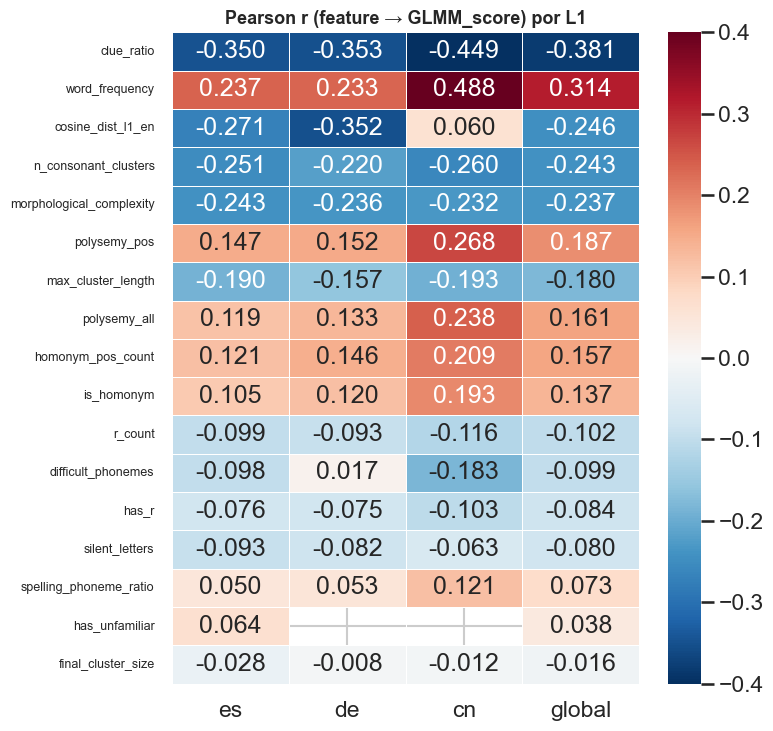

Features con MAYOR variación de importancia entre L1s:
  (la relación con dificultad depende del idioma)
  cosine_dist_l1_en               ES=-0.271  DE=-0.352  CN=+0.060  (rango=0.412)
  word_frequency                  ES=+0.237  DE=+0.233  CN=+0.488  (rango=0.256)
  difficult_phonemes              ES=-0.098  DE=+0.017  CN=-0.183  (rango=0.200)
  polysemy_pos                    ES=+0.147  DE=+0.152  CN=+0.268  (rango=0.121)
  polysemy_all                    ES=+0.119  DE=+0.133  CN=+0.238  (rango=0.119)
  clue_ratio                      ES=-0.350  DE=-0.353  CN=-0.449  (rango=0.099)
  is_homonym                      ES=+0.105  DE=+0.120  CN=+0.193  (rango=0.089)
  homonym_pos_count               ES=+0.121  DE=+0.146  CN=+0.209  (rango=0.088)


In [ ]:
# Heatmap: feature->target correlation by L1
pearson_by_l1 = pd.DataFrame(index=SELECTED_FEATURES, columns=L1S + ["global"])

for feat in SELECTED_FEATURES:
    valid = train_feat[[feat, TARGET]].dropna()
    if len(valid) > 2 and valid[feat].std() > 0:
        pearson_by_l1.loc[feat, "global"] = pearsonr(valid[feat], valid[TARGET])[0]
    for l1 in L1S:
        sub = train_feat[train_feat["L1"] == l1][[feat, TARGET]].dropna()
        if len(sub) > 2 and sub[feat].std() > 0:
            pearson_by_l1.loc[feat, l1] = pearsonr(sub[feat], sub[TARGET])[0]

pearson_by_l1 = pearson_by_l1.astype(float)
pearson_by_l1 = pearson_by_l1.loc[pearson_by_l1["global"].abs().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, max(len(SELECTED_FEATURES) * 0.45, 5)))
sns.heatmap(pearson_by_l1, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-0.4, vmax=0.4, linewidths=0.5, ax=ax)
ax.set_title("Pearson r (feature -> GLMM_score) by L1", fontsize=13, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_l1_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Features with highest variation across L1s
l1_range = pearson_by_l1[L1S].max(axis=1) - pearson_by_l1[L1S].min(axis=1)
l1_range = l1_range.sort_values(ascending=False)
print("Features with largest variation in importance across L1s:")
print("  (relationship with difficulty depends on language)")
for feat in l1_range.head(8).index:
    vals = {l1: pearson_by_l1.loc[feat, l1] for l1 in L1S}
    print(f"  {feat:30s}  ES={vals['es']:+.3f}  DE={vals['de']:+.3f}  CN={vals['cn']:+.3f}  "
          f"(range={l1_range[feat]:.3f})")


## 10. Cross-L1 Comparison - Parallel Items

Same English word, different L1s: how much does difficulty change?


Items paralelos (presentes en los 3 L1s): 6,091


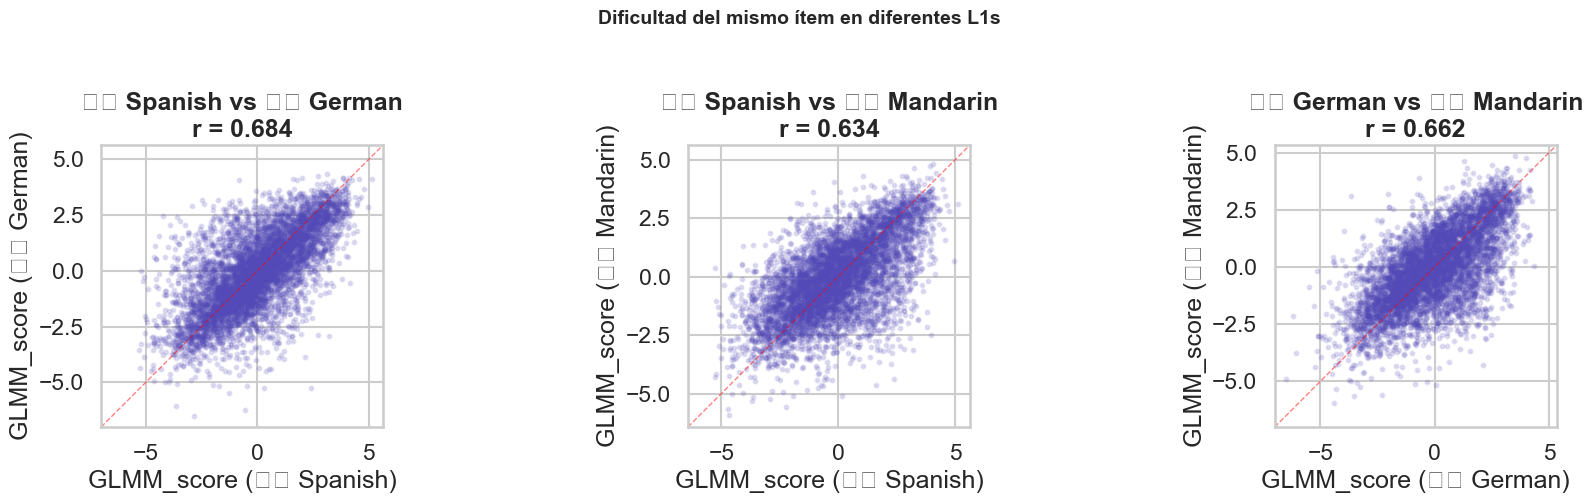


Correlación cruzada:


L1,cn,de,es
L1,,,
cn,1.000,0.662,0.634
de,0.662,1.000,0.684
es,0.634,0.684,1.000



Top 10 ítems con MAYOR diferencia de dificultad entre L1s:


,item_id,en_target_word,es,de,cn,range
0,2799,instrumental,2.41,-5.25,-4.38,7.65
1,5242,near,-1.60,-3.65,3.10,6.75
2,1855,android,-4.23,2.45,-2.99,6.67
3,4708,bye,3.98,2.55,-2.48,6.46
4,1243,running,-0.57,2.11,-4.30,6.41
5,5130,scan,3.22,-2.93,-3.14,6.36
6,4467,taken,1.61,-3.12,-4.65,6.25
7,5946,paranormal,2.26,-1.65,-3.72,5.99
8,4096,explosive,-3.59,2.40,-0.99,5.98
9,1828,calculated,2.12,-3.86,-3.15,5.98


In [ ]:
pivot = train.pivot_table(index="item_id", columns="L1", values=TARGET)
pivot = pivot.dropna()
print(f"Parallel items (present in all 3 L1s): {len(pivot):,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("es", "de"), ("es", "cn"), ("de", "cn")]

for ax, (l1_a, l1_b) in zip(axes, pairs):
    ax.scatter(pivot[l1_a], pivot[l1_b], alpha=0.15, s=8, color="#534AB7")
    r = pearsonr(pivot[l1_a], pivot[l1_b])[0]

    # Diagonal
    lim = [min(pivot[l1_a].min(), pivot[l1_b].min()) - 0.5,
           max(pivot[l1_a].max(), pivot[l1_b].max()) + 0.5]
    ax.plot(lim, lim, "r--", alpha=0.5, linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"GLMM_score ({L1_LABELS[l1_a]})")
    ax.set_ylabel(f"GLMM_score ({L1_LABELS[l1_b]})")
    ax.set_title(f"{L1_LABELS[l1_a]} vs {L1_LABELS[l1_b]}\nr = {r:.3f}", fontweight="bold")
    ax.set_aspect("equal")

plt.suptitle("Difficulty of the same item across different L1s", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_cross_l1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCross-language correlation:")
display(pivot.corr().round(3))

# Items with largest L1 difference
pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)
top_diff = pivot.nlargest(10, "range")
print("\nTop 10 items with the largest difficulty gap across L1s:")
merged = top_diff.reset_index().merge(
    train[["item_id", "en_target_word"]].drop_duplicates("item_id"), on="item_id")
display(merged[["item_id", "en_target_word", "es", "de", "cn", "range"]].round(2))


## 11. Easiest and Hardest Words

In [ ]:
for l1 in L1S:
    sub = train_feat[train_feat["L1"] == l1].sort_values(TARGET)
    show_cols = ["en_target_word", "en_target_pos", TARGET,
                 "word_length", "word_frequency", "difficult_phonemes", "polysemy_pos"]
    show_cols = [c for c in show_cols if c in sub.columns]

    print(f"\n{'=' * 70}")
    print(f"  {L1_LABELS[l1]}")
    print(f"{'=' * 70}")

    print(f"\n  10 HARDEST words (lowest GLMM):")
    display(sub[show_cols].head(10))

    print(f"\n  10 EASIEST words (highest GLMM):")
    display(sub[show_cols].tail(10))



══════════════════════════════════════════════════════════════════════
  🇪🇸 Spanish
══════════════════════════════════════════════════════════════════════

  🔴 10 más DIFÍCILES (GLMM más bajo):


,en_target_word,en_target_pos,GLMM_score,word_length,word_frequency,difficult_phonemes,polysemy_pos
5697,systematic,adjective,-5.286114,10,1.098612,0,2
5084,testament,noun,-5.271041,9,1.386294,0,4
5196,analogy,noun,-5.216882,7,1.609438,0,3
3669,projection,noun,-5.215601,10,2.708050,1,10
855,driving,adjective,-5.121635,7,1.098612,1,2
629,affirm,verb,-5.094026,6,2.708050,0,3
3976,analytical,adjective,-5.080692,10,0.693147,0,2
3552,shed,verb,-5.023753,4,2.302585,1,4
4233,positivity,noun,-5.022154,10,0.000000,0,5
3436,reason,verb,-4.996787,6,4.762174,1,3



  🟢 10 más FÁCILES (GLMM más alto):


,en_target_word,en_target_pos,GLMM_score,word_length,word_frequency,difficult_phonemes,polysemy_pos
2884,hour,noun,4.368442,4,4.753590,0,4
3597,no,misc,4.465405,2,5.293305,0,6
4879,radio,noun,4.467880,5,3.295837,0,3
3973,two,number,4.484412,3,6.295266,0,3
4484,german,adjective,4.556840,6,3.218876,0,1
5192,sun,noun,4.566609,3,4.077537,0,5
4496,orange,noun,4.662359,6,2.772589,0,5
2725,zoo,noun,4.761405,3,1.098612,1,1
3020,jet,noun,4.972895,3,1.609438,0,6
1563,dance,verb,5.143118,5,3.970292,0,3



══════════════════════════════════════════════════════════════════════
  🇩🇪 German
══════════════════════════════════════════════════════════════════════

  🔴 10 más DIFÍCILES (GLMM más bajo):


...

,en_target_word,en_target_pos,GLMM_score,word_length,word_frequency,difficult_phonemes,polysemy_pos
11897,day,noun,4.093449,3,5.857933,0,10
11283,sun,noun,4.101335,3,4.077537,0,5
11728,fit,adjective,4.115237,3,4.262680,0,3
7654,dance,verb,4.118859,5,3.970292,0,3
7088,ice,noun,4.156986,3,3.178054,0,8
10923,kiss,noun,4.179615,4,3.258097,0,4
6757,hungry,adjective,4.180015,6,2.197225,0,2
8866,eat,verb,4.180358,3,4.369448,0,6
6190,english,adjective,4.252494,7,4.060443,0,2
6584,bomb,noun,4.323405,4,2.564949,0,3



══════════════════════════════════════════════════════════════════════
  🇨🇳 Mandarin
══════════════════════════════════════════════════════════════════════

  🔴 10 más DIFÍCILES (GLMM más bajo):


,en_target_word,en_target_pos,GLMM_score,word_length,word_frequency,difficult_phonemes,polysemy_pos
13079,arresting,adjective,-5.930549,9,0.000000,1,1
16345,unchecked,adjective,-5.648856,9,0.000000,0,1
18060,descent,noun,-5.587278,7,1.791759,0,6
17265,advocacy,noun,-5.316085,8,0.693147,1,1
13949,becoming,adjective,-5.242444,8,0.000000,1,2
15265,phenomenal,adjective,-5.142599,10,0.000000,0,2
13545,instrumentally,adverb,-5.096004,14,0.000000,0,0
14661,commissioner,noun,-5.080932,12,1.791759,1,2
14276,studied,adjective,-5.029160,7,0.000000,0,1
12186,trying,adjective,-4.992504,6,1.098612,2,2



  🟢 10 más FÁCILES (GLMM más alto):


,en_target_word,en_target_pos,GLMM_score,word_length,word_frequency,difficult_phonemes,polysemy_pos
16458,food,noun,4.232183,4,3.401197,0,3
17014,kiss,noun,4.232546,4,3.258097,0,4
17357,kiss,verb,4.240950,4,3.258097,0,2
12430,story,noun,4.305230,5,4.158883,1,6
16683,dream,verb,4.317551,5,4.276666,1,2
15531,both,adverb,4.322863,4,0.000000,1,0
17643,boy,noun,4.453767,3,5.318120,0,4
12652,just,adverb,4.634827,4,5.886104,0,6
13719,cat,noun,4.758081,3,2.944439,0,8
18239,car,noun,4.834753,3,4.304065,1,5


## 12. Modeling Implications

### Key findings:

**1. Features with strongest signal:**
- `word_frequency` (WordNet) and `cosine_dist_l1_en` (L1↔EN distance) are usually among the strongest correlates of difficulty.
- Frequent words are easier. Words that are orthographically distant from their translation are harder.

**2. L1-specific interactions:**
- `difficult_phonemes` has different impact by L1 (CN has more English-absent phonemes than DE).
- `unfamiliar_letters` mainly affects ES (`w`, `k`).
- This supports training **per-L1** models (Closed) in addition to joint modeling (Open).

**3. Multicollinearity:**
- Several feature pairs are highly correlated (for example, `word_length` and `n_phonemes`).
- Automatic selection can reduce 22 features to around 17-19 without major signal loss.

**4. Non-normal distributions:**
- Most features are skewed (skew ≠ 0).
- XGBoost does not require normality. For transformers, appending features to `[CLS]` also does not require strict normality.

**5. Cross-L1 behavior:**
- The three languages are moderately correlated (r ≈ 0.7-0.8).
- Some items vary strongly across L1s, where L1-dependent features add value.

### Direct implications:
- **Closed Solo** (per-L1 transformer): captures language-specific patterns
- **Closed Hybrid** (transformer + features): L1-dependent phonological features complement the transformer
- **Open** (joint): leverages cross-lingual transfer, especially useful for CN with fewer effective samples
